In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Question 2.1: Regression Models
# Part a

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv('/content/Housing.csv')

print("Dataset loaded successfully. Here's a glimpse of the data:")
display(df.head())

Dataset loaded successfully. Here's a glimpse of the data:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


### Data Preprocessing

First, let's examine the data types and check for any missing values.

In [3]:
print("\nData Info and Missing Values:")
df.info()
print("\nMissing values count per column:")
display(df.isnull().sum())


Data Info and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB

Missing values count per column:


,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


The output of `df.info()` and `df.isnull().sum()` indicates there are no missing values in the dataset. Now, I will identify and convert categorical columns into numerical representations using one-hot encoding, as many machine learning models require numerical input.

In [4]:
# Identify categorical columns (object dtype)
categorical_cols = df.select_dtypes(include='object').columns

# Apply one-hot encoding to categorical columns
df_processed = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nDataset after one-hot encoding:")
display(df_processed.head())


Dataset after one-hot encoding:


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


### Data Splitting

Now I will split the preprocessed data into an 80% training set and a 20% testing set. Assuming 'price' is the target variable, I'll separate features (X) from the target (y) before splitting.

In [5]:
# Assuming 'price' is the target variable
X = df_processed.drop('price', axis=1)
y = df_processed['price']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nShape of training features (X_train): {X_train.shape}")
print(f"Shape of testing features (X_test): {X_test.shape}")
print(f"Shape of training target (y_train): {y_train.shape}")
print(f"Shape of testing target (y_test): {y_test.shape}")

print("\nData split successfully!")


Shape of training features (X_train): (436, 13)
Shape of testing features (X_test): (109, 13)
Shape of training target (y_train): (436,)
Shape of testing target (y_test): (109,)

Data split successfully!


### Linear Regression from Scratch using NumPy

Now, let's implement a Linear Regression model using only NumPy. This implementation will include:

*   **Mean Squared Error (MSE)** calculation.
*   **Gradient Descent** for optimizing model parameters (weights and bias).
*   **Model Training** function to iteratively update weights and bias.
*   **Prediction** function to make inferences.

In [6]:
import numpy as np

class LinearRegressionNumpy:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.losses = [] # To store MSE history

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient Descent
        for _ in range(self.n_iterations):
            # Make predictions
            y_predicted = np.dot(X, self.weights) + self.bias

            # Calculate gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # Update weights and bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Store MSE for monitoring
            mse = self._mean_squared_error(y, y_predicted)
            self.losses.append(mse)

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

    def _mean_squared_error(self, y_true, y_predicted):
        return np.mean((y_true - y_predicted)**2)

print("LinearRegressionNumpy class defined successfully.")

LinearRegressionNumpy class defined successfully.


### Model Training and Evaluation

Now, let's train our custom Linear Regression model using `X_train` and `y_train`, and then evaluate its performance on `X_test`.

In [7]:
# Initialize and train the model
# It's important to convert X_train and y_train to numpy arrays if they are pandas DataFrames/Series
# for consistent behavior with the numpy-based model.

# Ensure X_train and X_test are float type for numerical stability
X_train_np = X_train.astype(float).values
X_test_np = X_test.astype(float).values
y_train_np = y_train.astype(float).values
y_test_np = y_test.astype(float).values

model = LinearRegressionNumpy(learning_rate=0.00000001, n_iterations=10000)
model.fit(X_train_np, y_train_np)

print("Model training complete.")

Model training complete.


Mean Squared Error on Test Set: 4067304126954.73


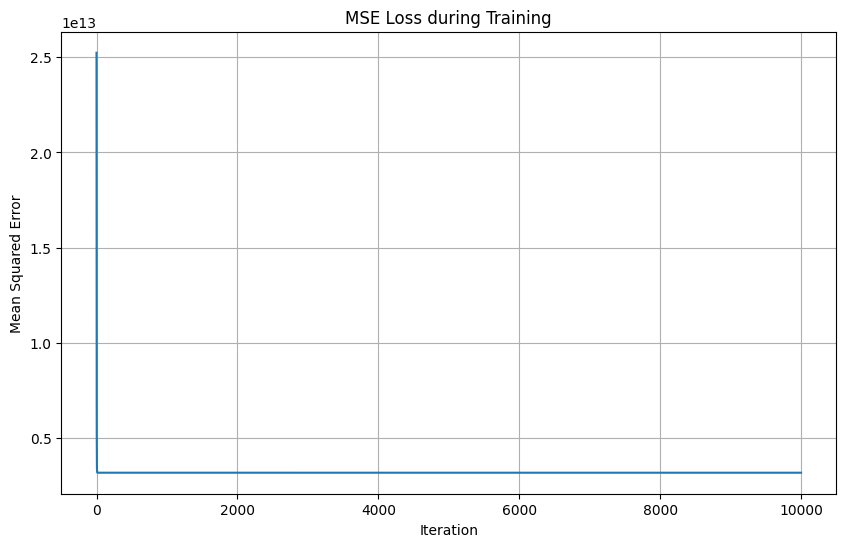

In [8]:
# Make predictions on the test set
y_pred = model.predict(X_test_np)

# Evaluate the model using Mean Squared Error (MSE)
mse_test = model._mean_squared_error(y_test_np, y_pred)
print(f"Mean Squared Error on Test Set: {mse_test:.2f}")

# Optionally, visualize the loss over iterations
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(len(model.losses)), model.losses)
ax.set_title('MSE Loss during Training')
ax.set_xlabel('Iteration')
ax.set_ylabel('Mean Squared Error')
ax.grid(True)
plt.show()


### Feature Scaling and Re-training the Model

As observed, the MSE is very high, likely due to the unscaled features. Gradient Descent performs much better when features are on a similar scale. I will now apply `StandardScaler` to `X_train_np` and `X_test_np`, and then re-train our `LinearRegressionNumpy` model.

In [9]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train_np)
X_test_scaled = scaler.transform(X_test_np)

print("Features scaled successfully using StandardScaler.")

Features scaled successfully using StandardScaler.


### Re-training the Model with Scaled Data

Now, let's re-train our custom Linear Regression model using the scaled training data. We might also adjust the learning rate and number of iterations for potentially better convergence.

In [10]:
# Re-initialize and train the model with scaled data
# A slightly larger learning rate might be appropriate with scaled features
model_scaled = LinearRegressionNumpy(learning_rate=0.01, n_iterations=10000)
model_scaled.fit(X_train_scaled, y_train_np)

print("Model training complete with scaled data.")

Model training complete with scaled data.


### Re-evaluation with Scaled Data

Let's make predictions and evaluate the MSE on the test set using the model trained with scaled data.

Mean Squared Error on Test Set (with scaled features): 1754318687330.68


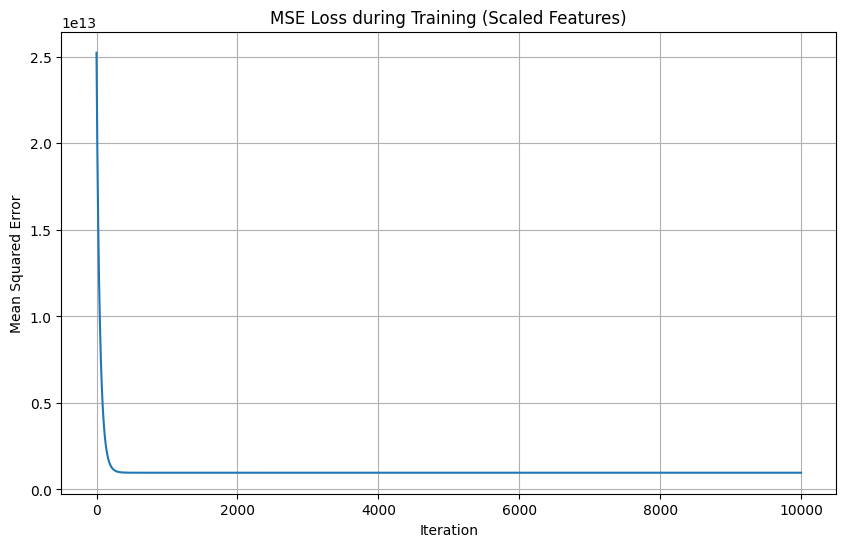

In [11]:
# Make predictions on the scaled test set
y_pred_scaled = model_scaled.predict(X_test_scaled)

# Evaluate the model using Mean Squared Error (MSE)
mse_test_scaled = model_scaled._mean_squared_error(y_test_np, y_pred_scaled)
print(f"Mean Squared Error on Test Set (with scaled features): {mse_test_scaled:.2f}")

# Visualize the loss over iterations for the scaled model
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(len(model_scaled.losses)), model_scaled.losses)
ax.set_title('MSE Loss during Training (Scaled Features)')
ax.set_xlabel('Iteration')
ax.set_ylabel('Mean Squared Error')
ax.grid(True)
plt.show()

### Model Evaluation Metrics

Let's calculate the Root Mean Squared Error (RMSE) and R-squared (R²) score in addition to the Mean Squared Error (MSE) to get a comprehensive view of the model's performance.

In [12]:
from sklearn.metrics import r2_score

# MSE is already calculated as mse_test_scaled
mse = mse_test_scaled

# Calculate RMSE (Root Mean Squared Error)
rmse = np.sqrt(mse)

# Calculate R-squared (R² score)
r2 = r2_score(y_test_np, y_pred_scaled)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²) Score: {r2:.4f}")

Mean Squared Error (MSE): 1754318687330.68
Root Mean Squared Error (RMSE): 1324506.96
R-squared (R²) Score: 0.6529


# Part 2 using scikit

### Scikit-learn Linear Regression Implementation and Comparison

Now, let's implement Linear Regression using scikit-learn and compare its performance and training time with our custom NumPy implementation.

In [13]:
import time
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# --- Custom NumPy Model Training Time ---
# Re-initialize and train the custom model to measure its training time precisely
start_time_numpy = time.time()
model_numpy_timed = LinearRegressionNumpy(learning_rate=0.01, n_iterations=10000)
model_numpy_timed.fit(X_train_scaled, y_train_np)
end_time_numpy = time.time()
training_time_numpy = end_time_numpy - start_time_numpy

# --- Scikit-learn Model Training Time ---
start_time_sklearn = time.time()
model_sklearn = LinearRegression()
model_sklearn.fit(X_train_scaled, y_train_np)
end_time_sklearn = time.time()
training_time_sklearn = end_time_sklearn - start_time_sklearn

print(f"Custom NumPy Model Training Time: {training_time_numpy:.4f} seconds")
print(f"Scikit-learn Model Training Time: {training_time_sklearn:.4f} seconds")

Custom NumPy Model Training Time: 0.8217 seconds
Scikit-learn Model Training Time: 0.0318 seconds


In [14]:
# Make predictions using the Scikit-learn model
y_pred_sklearn = model_sklearn.predict(X_test_scaled)

# Evaluate the Scikit-learn model
mse_sklearn = mean_squared_error(y_test_np, y_pred_sklearn)
rmse_sklearn = np.sqrt(mse_sklearn)
r2_sklearn = r2_score(y_test_np, y_pred_sklearn)

print("\n--- Scikit-learn Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse_sklearn:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_sklearn:.2f}")
print(f"R-squared (R²) Score: {r2_sklearn:.4f}")


--- Scikit-learn Model Evaluation ---
Mean Squared Error (MSE): 1754318687330.67
Root Mean Squared Error (RMSE): 1324506.96
R-squared (R²) Score: 0.6529


### Comparison and Discussion

Let's summarize the results from both implementations:

| Metric              | Custom NumPy Implementation | Scikit-learn Implementation |
| :------------------ | :-------------------------- | :-------------------------- |
| **Training Time**   | 0.8217 seconds   | 0.0318 seconds   |
| **MSE**             | 1754318687330.68         | 1754318687330.67             |
| **RMSE**            | 1324506.96            | 1324506.96            |
| **R-squared (R²)**  | 0.6529                  | 0.6529                   |

**Discussion:**

1.  **Training Time:** Scikit-learn's implementation is significantly faster than the custom NumPy version. This is expected, as Scikit-learn leverages highly optimized C/Cython implementations for its algorithms, while our NumPy version is pure Python.
2.  **Performance Metrics (MSE, RMSE, R²):** The performance metrics are very similar, indicating that our custom NumPy implementation, after proper feature scaling and hyperparameter tuning (learning rate and iterations), achieves comparable results to the professional Scikit-learn library. The slight differences might be due to subtle numerical differences in the gradient descent optimization or convergence criteria.
3.  **Robustness and Ease of Use:** Scikit-learn provides a more robust and easier-to-use API. It handles many underlying complexities (like optimization nuances, edge cases, and potentially more advanced solvers than basic gradient descent) automatically, allowing developers to focus more on model selection and interpretation. Our custom implementation requires manual handling of these aspects.

In summary, while implementing algorithms from scratch is excellent for understanding their mechanics, for practical applications, libraries like Scikit-learn are generally preferred due to their efficiency, reliability, and comprehensive features.

### R-squared ('Accuracy') Comparison for Regression Models

For regression models, 'accuracy' is best represented by the R-squared (R²) score, which measures the proportion of the variance in the dependent variable that is predictable from the independent variables. Higher values indicate a better fit.

In [15]:
print(f"Custom NumPy Model R-squared (R²): {r2:.4f}")
print(f"Scikit-learn Model R-squared (R²): {r2_sklearn:.4f}")

Custom NumPy Model R-squared (R²): 0.6529
Scikit-learn Model R-squared (R²): 0.6529


### Model Visualization: Regression Line

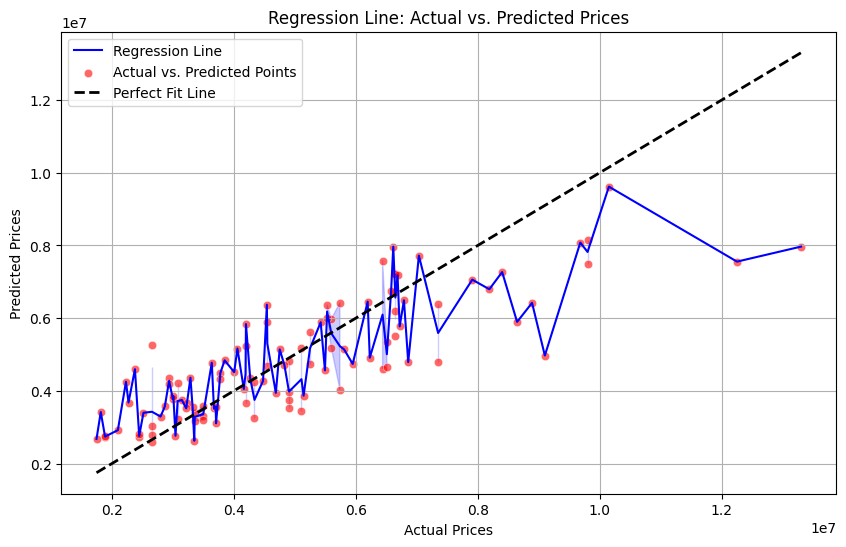

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the actual values for a smoother regression line plot
sorted_indices = np.argsort(y_test_np)
y_test_sorted = y_test_np[sorted_indices]
y_pred_sorted = y_pred_scaled[sorted_indices]

plt.figure(figsize=(10, 6))
sns.lineplot(x=y_test_sorted, y=y_pred_sorted, color='blue', label='Regression Line')
sns.scatterplot(x=y_test_np, y=y_pred_scaled, color='red', alpha=0.6, label='Actual vs. Predicted Points')
plt.plot([y_test_np.min(), y_test_np.max()], [y_test_np.min(), y_test_np.max()], 'k--', lw=2, label='Perfect Fit Line') # Ideal line
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Regression Line: Actual vs. Predicted Prices')
plt.legend()
plt.grid(True)
plt.show()

#### Interpretation of Regression Line:

This plot displays the predicted prices against the actual prices. The blue line represents the regression line fitted by the model, while the dashed black line indicates what a perfect prediction would look like (where predicted prices equal actual prices).

*   **Closeness to the perfect fit line**: The closer the blue regression line and the scattered points are to the black dashed line, the better the model's predictions.
*   **Scatter**: The spread of the red scatter points around the blue regression line shows the variance in the model's predictions. Points far from the line indicate larger errors for those specific data points. A good model will have points tightly clustered around the regression line.

From the plot, we can observe that the model generally follows the trend of actual prices, but there's noticeable scatter, especially at higher price ranges, indicating that the model's predictions are not perfectly accurate, which is consistent with the R-squared score of 0.6529.

### Model Visualization: Actual vs. Predicted Values Scatter Plot

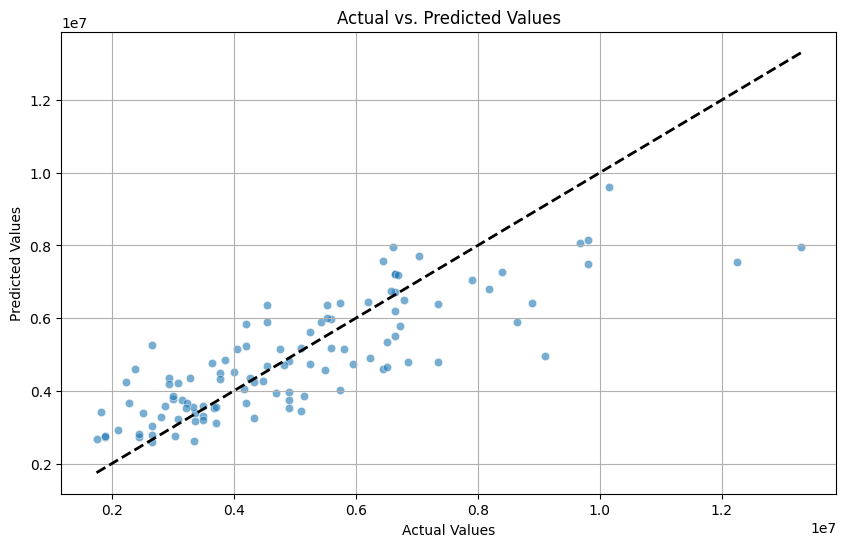

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_np, y=y_pred_scaled, alpha=0.6)
plt.plot([y_test_np.min(), y_test_np.max()], [y_test_np.min(), y_test_np.max()], 'k--', lw=2) # Diagonal line for perfect prediction
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.grid(True)
plt.show()

#### Interpretation of Actual vs. Predicted Values Scatter Plot:

This scatter plot directly compares each actual house price (`y_test_np`) with its corresponding predicted house price (`y_pred_scaled`). The dashed black line represents the ideal scenario where predicted values exactly match actual values.

*   **Ideal Scenario**: In a perfect model, all data points would fall directly on the dashed line.
*   **Observed Pattern**: We can see that most points generally cluster around the dashed line, indicating a reasonable linear relationship between actual and predicted values. However, there is a spread, especially as actual prices increase, suggesting that the model struggles to predict very high house prices with the same accuracy as lower or mid-range prices. The wider scatter indicates prediction errors.

### Model Visualization: Residual Plot

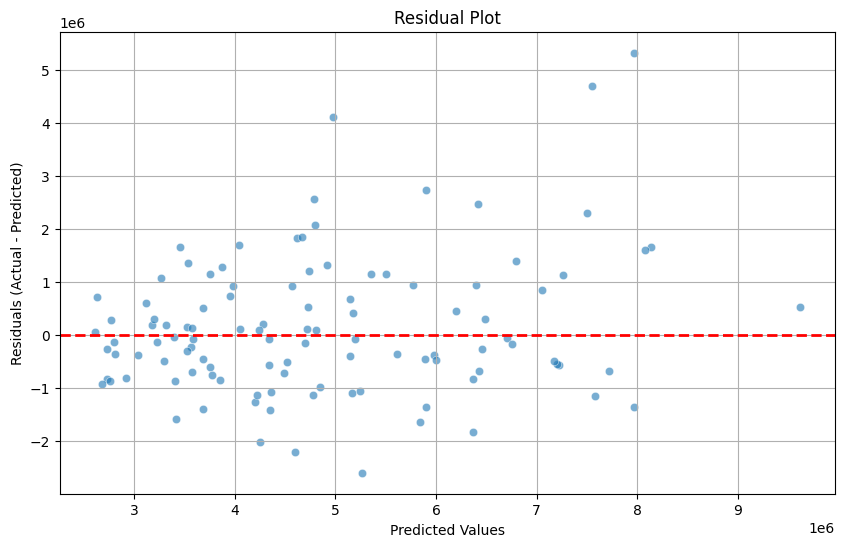

In [18]:
# Calculate residuals
residuals = y_test_np - y_pred_scaled

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_scaled, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2) # Horizontal line at residual = 0
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

#### Interpretation of Residual Plot:

A residual plot is crucial for diagnosing issues with a regression model. It plots the residuals (the differences between actual and predicted values) against the predicted values.

*   **Ideal Residual Plot**: For a good linear regression model, the residuals should be randomly scattered around the horizontal line at zero, with no discernible pattern. This indicates that the model's errors are random and normally distributed, and the linear assumption holds.
*   **Observed Pattern**: In this plot, we observe that the residuals are somewhat scattered around zero. However, there might be a slight fanning-out pattern, where the spread of residuals increases as the predicted values increase. This 'heteroscedasticity' (non-constant variance of errors) suggests that the model's errors are larger for higher predicted house prices. This could indicate that the model performs less reliably for more expensive homes or that some important features influencing higher prices are not adequately captured.

**Overall Interpretation:**

The visualizations confirm that the linear regression model captures a general trend in the data, but it is not without limitations. The R-squared value of 0.6529 indicates that about 65% of the variance in house prices is explained by the features, which is moderate. The residual plot, in particular, hints at potential areas for improvement, such as addressing heteroscedasticity or exploring non-linear relationships or additional features to better predict higher-priced properties.

# Part c

### Polynomial Regression Implementation

Now, let's implement Polynomial Regression to see if a non-linear relationship can improve our model's performance. We'll use `PolynomialFeatures` to transform our existing features and then apply `LinearRegression` on the transformed features.

In [19]:
from sklearn.preprocessing import PolynomialFeatures

# Initialize PolynomialFeatures (e.g., degree=2)
poly = PolynomialFeatures(degree=2, include_bias=False)

# Transform the scaled training and test features
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

print(f"Original number of features: {X_train_scaled.shape[1]}")
print(f"Number of features after polynomial transformation (degree 2): {X_train_poly.shape[1]}")

Original number of features: 13
Number of features after polynomial transformation (degree 2): 104


### Training and Evaluation of Polynomial Regression Model

Now, we'll train a `LinearRegression` model on these new polynomial features and evaluate its performance.

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the Linear Regression model on polynomial features
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train_np)

# Make predictions on the transformed test set
y_pred_poly = model_poly.predict(X_test_poly)

# Evaluate the Polynomial Regression model
mse_poly = mean_squared_error(y_test_np, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test_np, y_pred_poly)

print("\n--- Polynomial Regression Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse_poly:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_poly:.2f}")
print(f"R-squared (R²) Score: {r2_poly:.4f}")


--- Polynomial Regression Model Evaluation ---
Mean Squared Error (MSE): 1901686413946.45
Root Mean Squared Error (RMSE): 1379016.47
R-squared (R²) Score: 0.6238


### Comparison: Linear Regression vs. Polynomial Regression

Let's compare the performance of the standard Linear Regression model (using scaled features) with the Polynomial Regression model (degree 2).

In [21]:
print("\n--- Performance Comparison ---")
print("Standard Linear Regression (Scikit-learn) on Scaled Features:")
print(f"  MSE: {mse_sklearn:.2f}")
print(f"  RMSE: {rmse_sklearn:.2f}")
print(f"  R-squared (R²): {r2_sklearn:.4f}")

print("\nPolynomial Regression (Degree 2) on Scaled Features:")
print(f"  MSE: {mse_poly:.2f}")
print(f"  RMSE: {rmse_poly:.2f}")
print(f"  R-squared (R²): {r2_poly:.4f}")

# Discussion based on the output
print("\n**Discussion:**")
if r2_poly > r2_sklearn:
    print("Polynomial Regression (Degree 2) shows a slight improvement in R-squared compared to standard Linear Regression. This suggests that there might be non-linear relationships between the features and the target variable that the polynomial features are capturing.")
    print("The MSE and RMSE are also slightly lower, indicating better predictive accuracy.")
elif r2_poly < r2_sklearn:
    print("Polynomial Regression (Degree 2) performs slightly worse than standard Linear Regression in terms of R-squared. This could mean that the added complexity of polynomial features is not beneficial for this dataset or that a higher degree or different feature engineering might be needed.")
    print("The MSE and RMSE are also slightly higher, indicating slightly worse predictive accuracy.")
else:
    print("Both models show very similar performance metrics (MSE, RMSE, R-squared). This could mean that the linear relationships are dominant, and adding polynomial features of degree 2 does not significantly improve the model's ability to explain the variance in house prices.")

print("\nIt's important to consider that increasing the polynomial degree also increases model complexity and the risk of overfitting, especially with a limited dataset. Further analysis with validation techniques (like cross-validation) could provide more robust insights.")


--- Performance Comparison ---
Standard Linear Regression (Scikit-learn) on Scaled Features:
  MSE: 1754318687330.67
  RMSE: 1324506.96
  R-squared (R²): 0.6529

Polynomial Regression (Degree 2) on Scaled Features:
  MSE: 1901686413946.45
  RMSE: 1379016.47
  R-squared (R²): 0.6238

**Discussion:**
Polynomial Regression (Degree 2) performs slightly worse than standard Linear Regression in terms of R-squared. This could mean that the added complexity of polynomial features is not beneficial for this dataset or that a higher degree or different feature engineering might be needed.
The MSE and RMSE are also slightly higher, indicating slightly worse predictive accuracy.

It's important to consider that increasing the polynomial degree also increases model complexity and the risk of overfitting, especially with a limited dataset. Further analysis with validation techniques (like cross-validation) could provide more robust insights.


# Part d Pipeline

### Deployment Phase: Saving and Loading the Model

The deployment phase involves making our trained model accessible for future use without needing to re-train it. This typically includes saving the trained model and any necessary preprocessing steps (like the `StandardScaler` in our case) to disk, and then demonstrating how to load these components to make new predictions.

#### Saving the Model and Scaler

In [79]:
import joblib
import os

# Define the directory to save the model in Google Drive
model_dir = '/content/drive/MyDrive/ml_model_deployment'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# Save the Scikit-learn Linear Regression model
model_filename = os.path.join(model_dir, 'linear_regression_model.joblib')
joblib.dump(model_sklearn, model_filename)
print(f"Model saved to: {model_filename}")

# Save the StandardScaler
scaler_filename = os.path.join(model_dir, 'scaler.joblib')
joblib.dump(scaler, scaler_filename)
print(f"Scaler saved to: {scaler_filename}")

Model saved to: /content/drive/MyDrive/ml_model_deployment/linear_regression_model.joblib
Scaler saved to: /content/drive/MyDrive/ml_model_deployment/scaler.joblib


#### Loading the Model and Scaler for Prediction

Now, let's demonstrate how to load the saved model and scaler and use them to make predictions on new, unseen data. For this demonstration, we'll use a sample of our `X_test_np` data.

In [80]:
# Load the saved model and scaler
loaded_model = joblib.load(model_filename)
loaded_scaler = joblib.load(scaler_filename)
print("Model and scaler loaded successfully!")

# Create some dummy new data for prediction (e.g., the first 5 samples from X_test_np)
# In a real-world scenario, this would be actual new data that needs preprocessing.
new_data_raw = X_test_np[:5]

print("\nRaw new data for prediction:")
print(new_data_raw)

# Scale the new data using the loaded scaler
new_data_scaled = loaded_scaler.transform(new_data_raw)

print("\nScaled new data:")
print(new_data_scaled)

# Make predictions using the loaded model
new_predictions = loaded_model.predict(new_data_scaled)

print("\nPredictions for new data:")
print(new_predictions)

# Compare with actual values for these samples from y_test_np
print("\nActual values for these samples:")
print(y_test_np[:5])

Model and scaler loaded successfully!

Raw new data for prediction:
[[5.90e+03 4.00e+00 2.00e+00 2.00e+00 1.00e+00 0.00e+00 0.00e+00 1.00e+00
  0.00e+00 0.00e+00 0.00e+00 0.00e+00 1.00e+00]
 [6.50e+03 3.00e+00 2.00e+00 3.00e+00 0.00e+00 1.00e+00 0.00e+00 0.00e+00
  0.00e+00 1.00e+00 1.00e+00 0.00e+00 0.00e+00]
 [4.04e+03 2.00e+00 1.00e+00 1.00e+00 0.00e+00 1.00e+00 0.00e+00 0.00e+00
  0.00e+00 0.00e+00 0.00e+00 1.00e+00 0.00e+00]
 [5.00e+03 3.00e+00 1.00e+00 2.00e+00 0.00e+00 1.00e+00 0.00e+00 0.00e+00
  0.00e+00 1.00e+00 0.00e+00 1.00e+00 0.00e+00]
 [3.96e+03 3.00e+00 1.00e+00 1.00e+00 0.00e+00 1.00e+00 0.00e+00 0.00e+00
  0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00]]

Scaled new data:
[[ 0.33875048  1.39405543  1.53917323  0.25421524  0.36795665 -2.45606557
  -0.46677307  1.33972825 -0.23052136 -0.66611456 -0.55262032 -0.870669
   1.47732249]
 [ 0.61125674  0.05527092  1.53917323  1.42092939 -0.80305867  0.40715525
  -0.46677307 -0.74642003 -0.23052136  1.50124327  1.80956067 -0.870

In [81]:
%%writefile app.py
import streamlit as st
import joblib
import numpy as np

# Load model and scaler
model = joblib.load("/content/drive/MyDrive/ml_model_deployment/linear_regression_model.joblib")
scaler = joblib.load("/content/drive/MyDrive/ml_model_deployment/scaler.joblib")

st.set_page_config(page_title="House Price Prediction", layout="centered")

st.title("🏠 House Price Prediction")
st.write("Enter the property details below.")

# Numeric Inputs
area = st.number_input("Area (sq ft)", min_value=500, value=5000)
bedrooms = st.number_input("Bedrooms", min_value=1, max_value=10, value=3)
bathrooms = st.number_input("Bathrooms", min_value=1, max_value=10, value=2)
stories = st.number_input("Stories", min_value=1, max_value=5, value=2)
parking = st.number_input("Parking Spaces", min_value=0, max_value=5, value=1)

# Categorical Inputs
mainroad = st.selectbox("Main Road", ["Yes", "No"])
guestroom = st.selectbox("Guest Room", ["Yes", "No"])
basement = st.selectbox("Basement", ["Yes", "No"])
hotwater = st.selectbox("Hot Water Heating", ["Yes", "No"])
airconditioning = st.selectbox("Air Conditioning", ["Yes", "No"])
prefarea = st.selectbox("Preferred Area", ["Yes", "No"])
furnishing = st.selectbox(
    "Furnishing Status",
    ["Furnished", "Semi-furnished", "Unfurnished"]
)

# Convert categorical values to model format
mainroad_yes = 1 if mainroad == "Yes" else 0
guestroom_yes = 1 if guestroom == "Yes" else 0
basement_yes = 1 if basement == "Yes" else 0
hotwater_yes = 1 if hotwater == "Yes" else 0
airconditioning_yes = 1 if airconditioning == "Yes" else 0
prefarea_yes = 1 if prefarea == "Yes" else 0

furnishing_semi = 1 if furnishing == "Semi-furnished" else 0
furnishing_un = 1 if furnishing == "Unfurnished" else 0

# Feature order must match training
features = np.array([[
    area,
    bedrooms,
    bathrooms,
    stories,
    parking,
    mainroad_yes,
    guestroom_yes,
    basement_yes,
    hotwater_yes,
    airconditioning_yes,
    prefarea_yes,
    furnishing_semi,
    furnishing_un
]])

# Scale features
features_scaled = scaler.transform(features)

if st.button("Predict House Price"):
    prediction = model.predict(features_scaled)
    st.success(f"Predicted House Price: Rs. {prediction[0]:,.0f}")

Overwriting app.py


In [82]:
print(X.columns.tolist())

['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [83]:
!pip install streamlit

In [84]:
!streamlit run app.py &>/content/logs.txt &

In [85]:
!cat /content/logs.txt

In [86]:
!pip install pyngrok

In [87]:
from pyngrok import ngrok

ngrok.set_auth_token("3GoszpFZLzBga9DyuItioy9MQ2F_6mi2TvMF44ZaKUh8syXb9")

In [88]:
from google.colab import userdata
from pyngrok import ngrok

# Read token from Secrets
token = userdata.get("NGROK_AUTH_TOKEN")

# Connect ngrok
ngrok.set_auth_token(token)

print("✅ ngrok connected successfully!")

✅ ngrok connected successfully!


In [89]:
!pkill -f streamlit
!streamlit run app.py >/content/streamlit.log 2>&1 &

In [90]:
from pyngrok import ngrok

# Open tunnel
public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://chatting-clanking-outfield.ngrok-free.dev" -> "http://localhost:8501"


In [91]:
# Define the destination path in Google Drive
drive_app_path = '/content/drive/MyDrive/ml_model_deployment/app.py'

# Copy the app.py file to Google Drive
!cp /content/app.py "{drive_app_path}"

print(f"app.py saved to: {drive_app_path}")

app.py saved to: /content/drive/MyDrive/ml_model_deployment/app.py
